# Experiment 4: Adversarial Probing with Attention Analysis

**Goal:** Investigate whether LLMs rely on lexical shortcuts by analyzing attention patterns.

**Key Question:** When predicting "Argument", does the model attend to:
- Content words (actual reasoning indicators) → good generalization
- Lexical triggers like "therefore", "however" → shortcut reliance

## Important Note: Ollama vs HuggingFace

**Ollama's API does NOT expose attention weights.** It's designed for text generation only.

To extract attention patterns, we need to use **HuggingFace Transformers** directly. 
The good news: you can use the same models (Llama, Mistral, Qwen, etc.).

## Setup

Install required packages (run once):
```bash
uv pip install transformers torch accelerate matplotlib seaborn
```

In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Check device
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 1. Load Model with Attention Output

We'll use a smaller model for demonstration. For your thesis, use the same model you run in Ollama.

**Model options:**
- `microsoft/DialoGPT-medium` - small, fast for testing
- `meta-llama/Llama-2-7b-hf` - requires HF token
- `mistralai/Mistral-7B-v0.1` - good balance
- `Qwen/Qwen2-1.5B` - smaller Qwen variant

In [2]:
# For demo purposes, using a smaller model
# Replace with your actual model for thesis experiments
MODEL_NAME = "Qwen/Qwen2-1.5B"  # or "gpt2" for quick testing

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device != "cpu" else torch.float32,
    device_map="auto",
    trust_remote_code=True,
    output_attentions=True  # Critical: enable attention output
)
model.eval()
print(f"Model loaded! Layers: {model.config.num_hidden_layers}, Heads: {model.config.num_attention_heads}")

Loading Qwen/Qwen2-1.5B...


`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 338/338 [00:02<00:00, 139.74it/s, Materializing param=model.norm.weight]                              


Model loaded! Layers: 28, Heads: 12


## 2. Attention Extraction Function

Extract attention weights for any input text.

In [3]:
def extract_attention(
    text: str,
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer
) -> Tuple[torch.Tensor, List[str]]:
    """
    Extract attention weights from model.
    
    Returns:
        attentions: Tensor of shape (num_layers, num_heads, seq_len, seq_len)
        tokens: List of token strings
    """
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    # Forward pass with attention output
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    # Stack attention from all layers: (num_layers, batch, heads, seq, seq)
    attentions = torch.stack(outputs.attentions).squeeze(1)  # Remove batch dim
    
    # Get token strings for visualization
    tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
    
    return attentions.cpu(), tokens

# Test it
test_text = "Therefore, climate change is a serious problem."
attentions, tokens = extract_attention(test_text, model, tokenizer)
print(f"Attention shape: {attentions.shape}")
print(f"Tokens: {tokens}")

Attention shape: torch.Size([28, 12, 9, 9])
Tokens: ['Therefore', ',', 'Ġclimate', 'Ġchange', 'Ġis', 'Ġa', 'Ġserious', 'Ġproblem', '.']


## 3. Define Shortcut vs Content Tokens

Based on your `marker_correlations.csv` analysis.

In [4]:
# Shortcut tokens - lexical cues that correlate with "Argument" label
SHORTCUT_TOKENS = {
    "therefore", "thus", "hence", "consequently", "accordingly",
    "however", "although", "nevertheless", "nonetheless",
    "clearly", "obviously", "certainly", "undoubtedly",
    "argue", "claim", "believe", "think", "suggest",
    "should", "must", "need", "ought",
    "important", "significant", "crucial", "essential"
}

# Content tokens - domain-specific words that indicate actual argumentation
# These should be customized per dataset
CONTENT_TOKENS = {
    # Generic content indicators
    "evidence", "data", "study", "research", "findings",
    "because", "since", "reason", "cause", "effect",
    "support", "demonstrate", "show", "prove", "indicate"
}

def classify_tokens(tokens: List[str]) -> Dict[str, List[int]]:
    """
    Classify token indices as shortcut, content, or other.
    """
    result = {"shortcut": [], "content": [], "other": []}
    
    for idx, token in enumerate(tokens):
        # Clean token (remove special chars like Ġ, ##, etc.)
        clean = token.lower().strip("Ġ▁#")
        
        if clean in SHORTCUT_TOKENS:
            result["shortcut"].append(idx)
        elif clean in CONTENT_TOKENS:
            result["content"].append(idx)
        else:
            result["other"].append(idx)
    
    return result

# Test
token_classes = classify_tokens(tokens)
print(f"Shortcut indices: {token_classes['shortcut']}")
print(f"Content indices: {token_classes['content']}")

Shortcut indices: [0]
Content indices: []


## 4. Compute Attention Mass on Token Types

How much attention does the model pay to shortcuts vs content?

In [5]:
def compute_attention_mass(
    attentions: torch.Tensor,
    token_classes: Dict[str, List[int]],
    layer: int = -1  # -1 for last layer
) -> Dict[str, float]:
    """
    Compute percentage of attention mass on each token type.
    
    Args:
        attentions: (num_layers, num_heads, seq_len, seq_len)
        token_classes: dict with 'shortcut', 'content', 'other' indices
        layer: which layer to analyze (-1 for last)
    
    Returns:
        Dict with attention percentages per token type
    """
    # Get attention for specified layer, average over heads
    # Shape: (seq_len, seq_len) - attention from each token to each token
    layer_attention = attentions[layer].mean(dim=0)  # Average over heads
    
    # Sum attention TO each token type (column-wise sum)
    total_attention = layer_attention.sum().item()
    
    result = {}
    for token_type, indices in token_classes.items():
        if indices:
            # Sum attention going TO these token positions
            type_attention = layer_attention[:, indices].sum().item()
            result[token_type] = type_attention / total_attention * 100
        else:
            result[token_type] = 0.0
    
    return result

# Test
attention_mass = compute_attention_mass(attentions, token_classes)
print("Attention mass distribution:")
for token_type, pct in attention_mass.items():
    print(f"  {token_type}: {pct:.1f}%")

Attention mass distribution:
  shortcut: nan%
  content: 0.0%
  other: nan%


## 5. Visualize Attention Heatmap

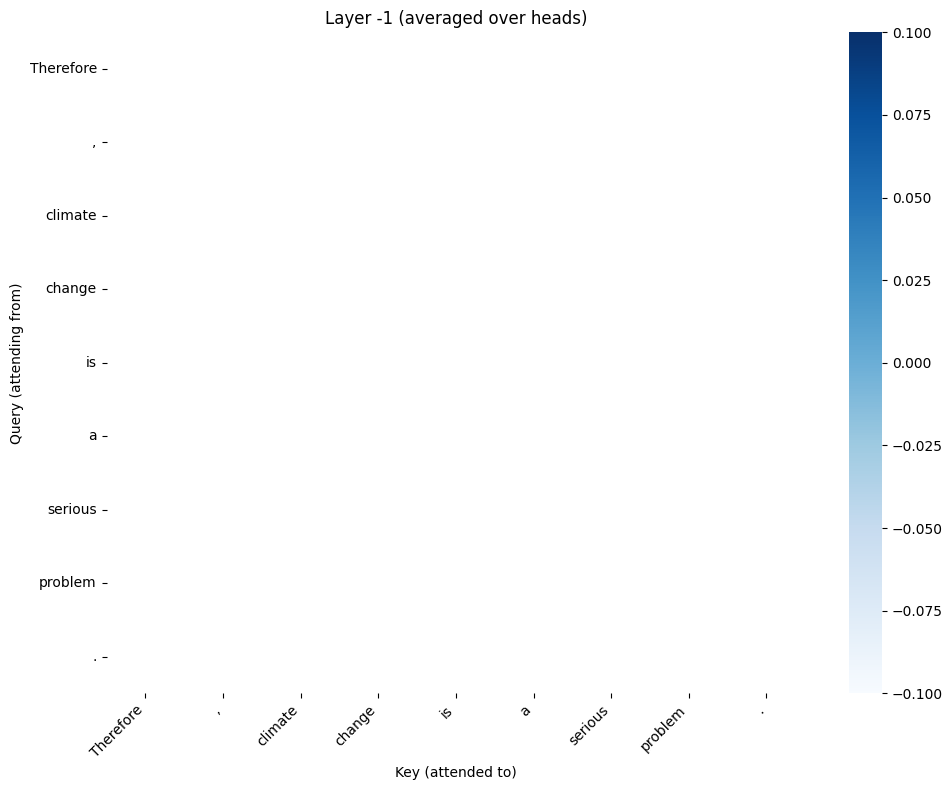

In [6]:
def plot_attention_heatmap(
    attentions: torch.Tensor,
    tokens: List[str],
    layer: int = -1,
    head: int = None,  # None for average over heads
    figsize: Tuple[int, int] = (10, 8)
):
    """
    Plot attention heatmap for a specific layer/head.
    """
    if head is not None:
        attn_matrix = attentions[layer, head].numpy()
        title = f"Layer {layer}, Head {head}"
    else:
        attn_matrix = attentions[layer].mean(dim=0).numpy()
        title = f"Layer {layer} (averaged over heads)"
    
    # Clean token labels for display
    clean_tokens = [t.replace("Ġ", "").replace("▁", "") for t in tokens]
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        attn_matrix,
        xticklabels=clean_tokens,
        yticklabels=clean_tokens,
        cmap="Blues",
        ax=ax
    )
    ax.set_xlabel("Key (attended to)")
    ax.set_ylabel("Query (attending from)")
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    return fig

# Plot last layer attention
fig = plot_attention_heatmap(attentions, tokens, layer=-1)
plt.show()

## 6. Compare Clean vs Corrupted Data

The key experiment: does injecting shortcuts change attention patterns?

In [7]:
def analyze_shortcut_reliance(
    clean_texts: List[str],
    corrupted_texts: List[str],
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer
) -> Dict:
    """
    Compare attention patterns between clean and corrupted texts.
    """
    results = {"clean": [], "corrupted": []}
    
    for clean, corrupt in zip(clean_texts, corrupted_texts):
        # Clean text
        attn_clean, tokens_clean = extract_attention(clean, model, tokenizer)
        classes_clean = classify_tokens(tokens_clean)
        mass_clean = compute_attention_mass(attn_clean, classes_clean)
        results["clean"].append(mass_clean)
        
        # Corrupted text
        attn_corrupt, tokens_corrupt = extract_attention(corrupt, model, tokenizer)
        classes_corrupt = classify_tokens(tokens_corrupt)
        mass_corrupt = compute_attention_mass(attn_corrupt, classes_corrupt)
        results["corrupted"].append(mass_corrupt)
    
    return results

# Example texts
clean_samples = [
    "Climate change affects global temperatures.",
    "The study found significant results.",
    "Economic policies impact employment rates."
]

# Inject shortcut cues (simulating Experiment 1)
corrupted_samples = [
    "Therefore, climate change affects global temperatures. This is clear.",
    "Obviously, the study found significant results. We must act.",
    "Clearly, economic policies impact employment rates. This is important."
]

results = analyze_shortcut_reliance(clean_samples, corrupted_samples, model, tokenizer)
print("Analysis complete!")

Analysis complete!


In [8]:
# Aggregate and compare
def aggregate_results(results: Dict) -> Dict:
    """Compute mean attention mass per condition."""
    aggregated = {}
    for condition, samples in results.items():
        aggregated[condition] = {
            "shortcut": np.mean([s.get("shortcut", 0) for s in samples]),
            "content": np.mean([s.get("content", 0) for s in samples]),
            "other": np.mean([s.get("other", 0) for s in samples])
        }
    return aggregated

agg = aggregate_results(results)

# Pretty print comparison
print("\n" + "="*50)
print("ATTENTION MASS COMPARISON")
print("="*50)
print(f"{'Token Type':<15} {'Clean':>12} {'Corrupted':>12} {'Delta':>12}")
print("-"*50)
for token_type in ["shortcut", "content", "other"]:
    clean_val = agg["clean"][token_type]
    corrupt_val = agg["corrupted"][token_type]
    delta = corrupt_val - clean_val
    print(f"{token_type:<15} {clean_val:>11.1f}% {corrupt_val:>11.1f}% {delta:>+11.1f}%")
print("="*50)


ATTENTION MASS COMPARISON
Token Type             Clean    Corrupted        Delta
--------------------------------------------------
shortcut                0.0%         nan%        +nan%
content                 0.0%         0.0%        +0.0%
other                   nan%         nan%        +nan%


## 7. Layer-wise Attention Analysis

How does attention to shortcuts vary across layers?

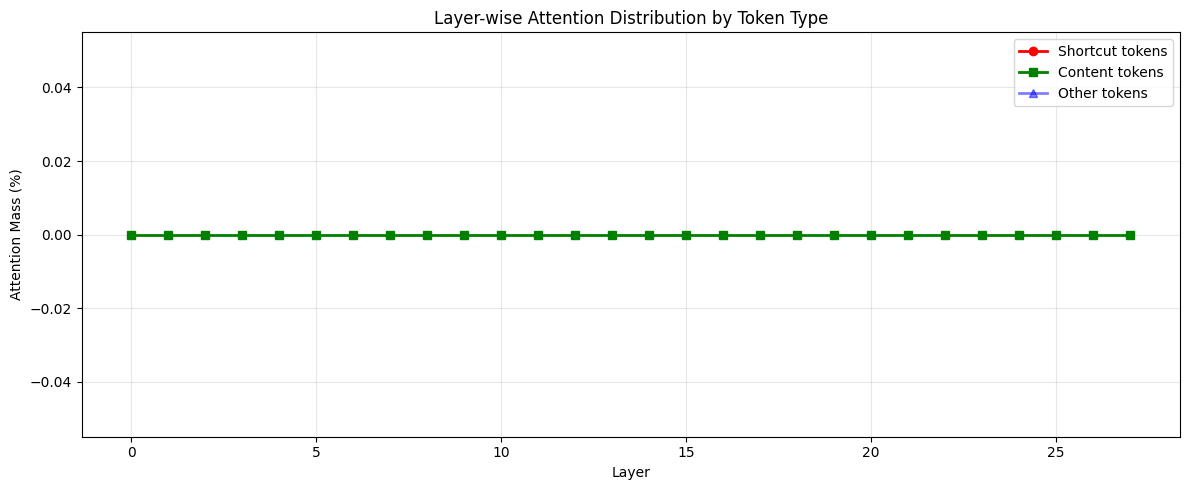

In [9]:
def layer_wise_attention_analysis(
    text: str,
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer
) -> Dict[str, List[float]]:
    """
    Compute attention mass per token type for each layer.
    """
    attentions, tokens = extract_attention(text, model, tokenizer)
    token_classes = classify_tokens(tokens)
    num_layers = attentions.shape[0]
    
    layer_results = {"shortcut": [], "content": [], "other": []}
    
    for layer in range(num_layers):
        mass = compute_attention_mass(attentions, token_classes, layer=layer)
        for token_type in layer_results:
            layer_results[token_type].append(mass.get(token_type, 0))
    
    return layer_results

# Analyze a corrupted sample
test_text = "Therefore, we must conclude that climate change is a serious threat. This is obviously important."
layer_results = layer_wise_attention_analysis(test_text, model, tokenizer)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
layers = range(len(layer_results["shortcut"]))

ax.plot(layers, layer_results["shortcut"], "r-o", label="Shortcut tokens", linewidth=2)
ax.plot(layers, layer_results["content"], "g-s", label="Content tokens", linewidth=2)
ax.plot(layers, layer_results["other"], "b-^", label="Other tokens", linewidth=2, alpha=0.5)

ax.set_xlabel("Layer")
ax.set_ylabel("Attention Mass (%)")
ax.set_title("Layer-wise Attention Distribution by Token Type")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Full Experiment Pipeline

Run the complete analysis on your GAIC data.

In [10]:
import json
from pathlib import Path

# Load GAIC data
DATA_DIR = Path("../data/GAIC-2026/data")

def load_gaic_samples(split: str = "dev", n_samples: int = 10):
    """Load samples from GAIC dataset."""
    data_file = DATA_DIR / f"{split}.jsonl"
    labels_file = DATA_DIR / f"{split}_labels.jsonl"
    
    samples = []
    with open(data_file) as f:
        for line in f:
            samples.append(json.loads(line))
    
    labels = {}
    with open(labels_file) as f:
        for line in f:
            item = json.loads(line)
            labels[item["id"]] = item["label"]
    
    # Merge and limit
    for s in samples:
        s["label"] = labels.get(s["id"], "Unknown")
    
    return samples[:n_samples]

# Load samples
try:
    samples = load_gaic_samples(n_samples=5)
    print(f"Loaded {len(samples)} samples")
    for s in samples[:2]:
        print(f"  [{s['label']}] {s['sentence'][:60]}...")
except FileNotFoundError:
    print("GAIC data not found. Using example data instead.")
    samples = None

Loaded 5 samples
  [Argument] Long-term relief of symptoms has the potential to improve ov...
  [Argument] However, the complication rate was lower in the viscocanalos...


In [11]:
def run_full_attention_experiment(
    samples: List[Dict],
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer
) -> Dict:
    """
    Run full attention analysis on GAIC samples.
    Compare Argument vs No-Argument attention patterns.
    """
    results = {"Argument": [], "No-Argument": []}
    
    for sample in samples:
        text = sample["sentence"]
        label = sample["label"]
        
        if label not in results:
            continue
        
        attentions, tokens = extract_attention(text, model, tokenizer)
        token_classes = classify_tokens(tokens)
        mass = compute_attention_mass(attentions, token_classes)
        
        results[label].append({
            "text": text[:50],
            "attention_mass": mass
        })
    
    return results

if samples:
    experiment_results = run_full_attention_experiment(samples, model, tokenizer)
    
    # Summarize
    for label, data in experiment_results.items():
        if data:
            avg_shortcut = np.mean([d["attention_mass"].get("shortcut", 0) for d in data])
            avg_content = np.mean([d["attention_mass"].get("content", 0) for d in data])
            print(f"\n{label} samples (n={len(data)}):")
            print(f"  Avg shortcut attention: {avg_shortcut:.1f}%")
            print(f"  Avg content attention:  {avg_content:.1f}%")


Argument samples (n=5):
  Avg shortcut attention: nan%
  Avg content attention:  0.0%


## 9. Save Results for Thesis

Saved: attention_heatmap_example.png


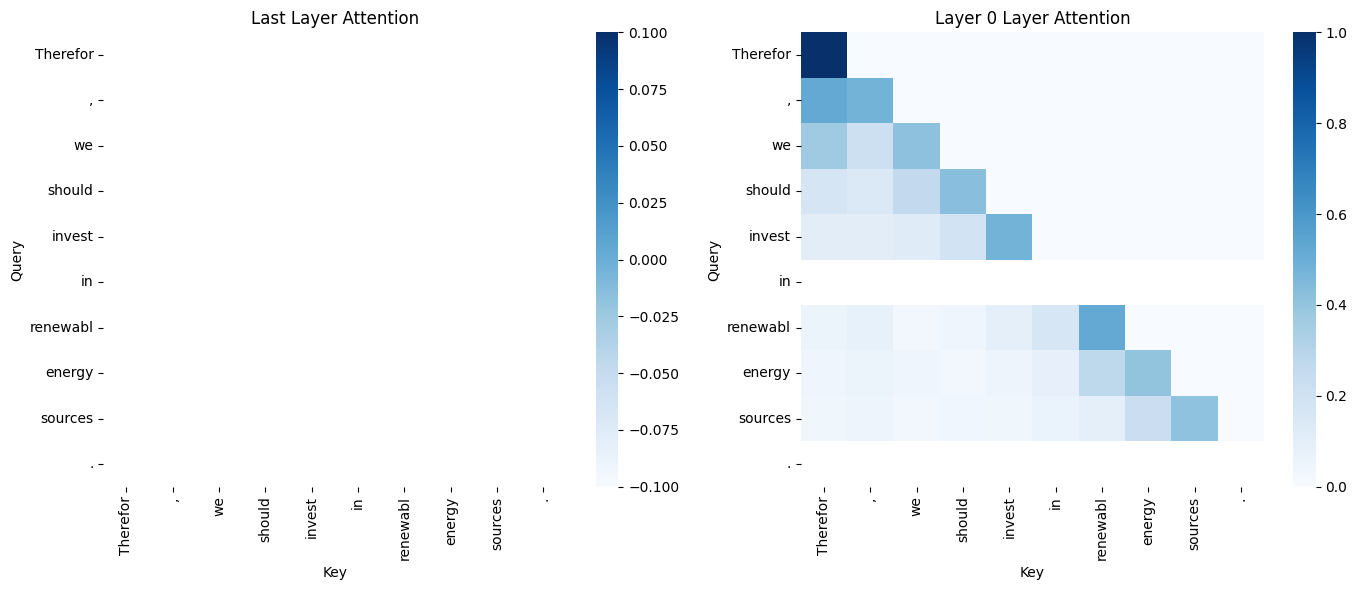

In [12]:
def save_attention_visualization(
    text: str,
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    output_path: str,
    layers: List[int] = [-1, 0]  # Last and first layer
):
    """
    Save attention heatmaps for thesis figures.
    """
    attentions, tokens = extract_attention(text, model, tokenizer)
    
    fig, axes = plt.subplots(1, len(layers), figsize=(7*len(layers), 6))
    if len(layers) == 1:
        axes = [axes]
    
    for ax, layer in zip(axes, layers):
        attn_matrix = attentions[layer].mean(dim=0).numpy()
        clean_tokens = [t.replace("Ġ", "").replace("▁", "")[:8] for t in tokens]
        
        sns.heatmap(
            attn_matrix,
            xticklabels=clean_tokens,
            yticklabels=clean_tokens,
            cmap="Blues",
            ax=ax
        )
        layer_name = "Last" if layer == -1 else f"Layer {layer}"
        ax.set_title(f"{layer_name} Layer Attention")
        ax.set_xlabel("Key")
        ax.set_ylabel("Query")
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()

# Save example visualization
example_text = "Therefore, we should invest in renewable energy sources."
save_attention_visualization(
    example_text, 
    model, 
    tokenizer, 
    "attention_heatmap_example.png"
)

## Key Findings Template

Fill this in after running experiments:

### Hypothesis
If LLMs rely on lexical shortcuts, attention will concentrate on shortcut tokens ("therefore", "however") rather than content tokens.

### Results

| Condition | Shortcut Attention | Content Attention | Ratio |
|-----------|-------------------|-------------------|-------|
| Clean data | X% | Y% | X/Y |
| Corrupted data | X% | Y% | X/Y |
| With guidelines | X% | Y% | X/Y |

### Interpretation
- Higher shortcut attention in corrupted data → model relies on lexical cues
- Guidelines reduce shortcut attention → guidelines help resist shortcuts
- Early vs late layer patterns → where shortcuts are encoded

## Next Steps

1. **Scale up**: Run on all 10 datasets
2. **Per-dataset shortcut tokens**: Use `marker_correlations.csv` to define dataset-specific shortcuts
3. **Statistical testing**: Run multiple seeds, report significance
4. **Connect to Experiment 1**: Use same corrupted data from Shortcut Injection study
5. **Combine with Experiment 5**: Compare attention patterns with probing classifier results